<a href="https://colab.research.google.com/github/kuruvajayanth12/Neural-Networks-and-Deep-Learning/blob/main/NNDL_EXP9_FPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics opencv-python

In [2]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import base64
import cv2
import numpy as np

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = '📸 Capture';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(track => track.stop());
            div.remove();

            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')

    display(js)
    data = eval_js('takePhoto({})'.format(quality))

    binary = base64.b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

In [3]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

<IPython.core.display.Javascript object>


0: 384x640 1 person, 1 tie, 153.3ms
Speed: 3.5ms preprocess, 153.3ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)
FPS: 6.0


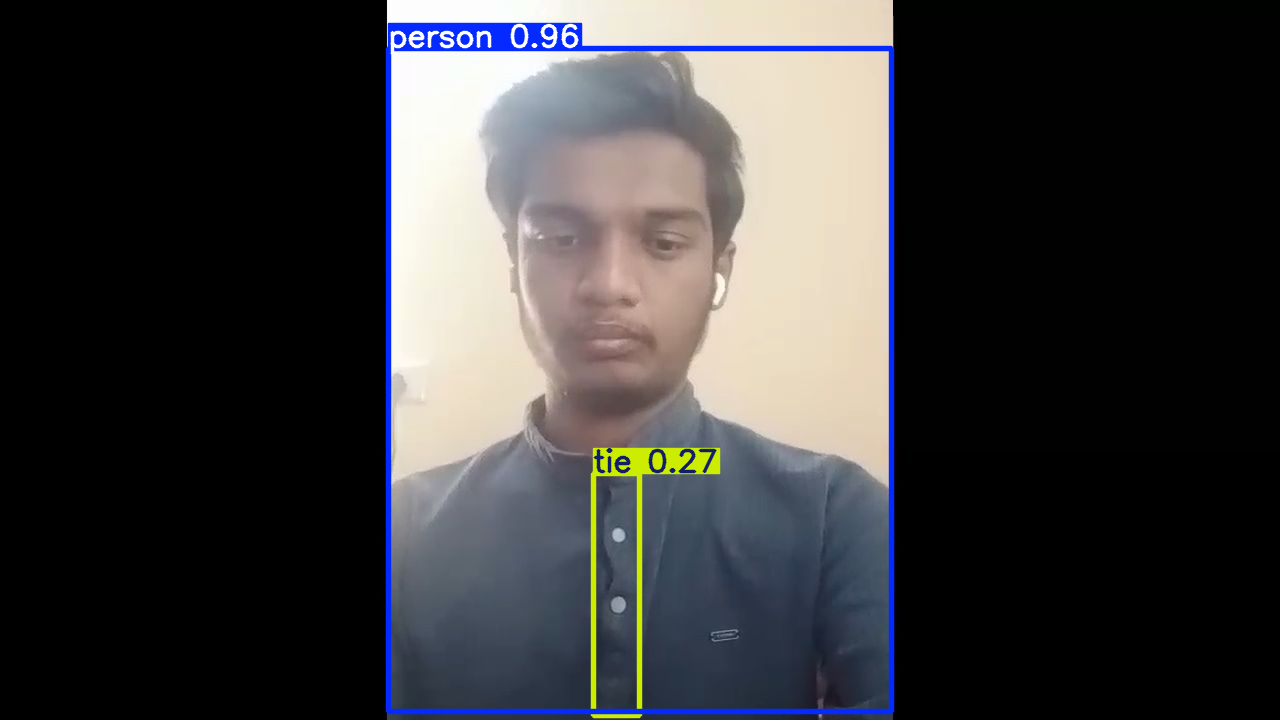

In [6]:
# -----------------------------
# Capture + Detect
# -----------------------------
img_path = take_photo()

img = cv2.imread(img_path)

# 👉 ADD FPS HERE
import time
start = time.time()

results = model(img)   # detection happens here

end = time.time()

fps = 1 / (end - start)
print("FPS:", round(fps, 2))

# -----------------------------
# Show result
# -----------------------------
annotated = results[0].plot()

from google.colab.patches import cv2_imshow
cv2_imshow(annotated)